### [ 이진화 / 쓰레시 홀딩 - 최적의 값 찾기 ] <hr>
- 방법1) 직접 임계값 변경하면서 최적값 찾기
- 방법2) 오츠의 알고리즘으로 찾기
- 방법3) 적응형 임계값 찾기

In [29]:
import numpy as np, cv2, matplotlib.pyplot as plt, koreanize_matplotlib, sys
sys.path.append(r'C:\Users\Win11Pro\Desktop\KDT-14\[7]_CVISION')
from cv_utils import printPolts

In [30]:
# 데이터 준비
IMG_FILE = '../Data/images/scaned_paper.jpg'

In [31]:
# 이미지 데이터 로딩 및 기본 정보 확인
img = cv2.imread(IMG_FILE, cv2.IMREAD_GRAYSCALE)
print(f'[기본정보] shape : {img.shape}, ndim : {img.ndim}, dtype : {img.dtype}')

[기본정보] shape : (450, 400), ndim : 2, dtype : uint8


최대 : 255, 최소 : 12, 평균 : 152.77648333333335


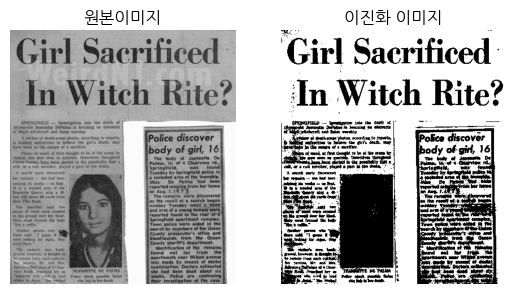

In [32]:
# 이진화 - opencv 방식
# 임계값/ 쓰레시홀드 값 설정
print(f'최대 : {img.max()}, 최소 : {img.min()}, 평균 : {img.mean()}')

TH_VALUE, MAX_VALUE = int(img.mean()), 255

ret, bin = cv2.threshold(img, TH_VALUE, MAX_VALUE, cv2.THRESH_BINARY)

# 시각화 : 원본, 이진화
printPolts(1 ,2 ,['원본이미지', '이진화 이미지'], [img, bin], ['gray'])

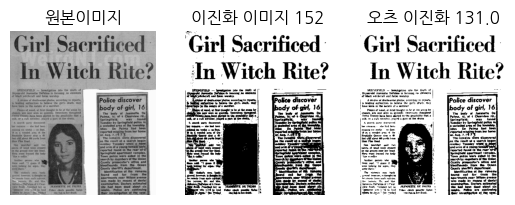

In [33]:
# 이진화 - opencv 방식
# 임계값/ 쓰레시홀드 값 설정
t, t_otsu = cv2.threshold(img, 0, MAX_VALUE, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

# 시각화 : 원본, 이진화, 오츠 이진화
printPolts(1, 3, ['원본이미지', f'이진화 이미지 {TH_VALUE}', f'오츠 이진화 {t}'], [img, bin, t_otsu], ['gray'])

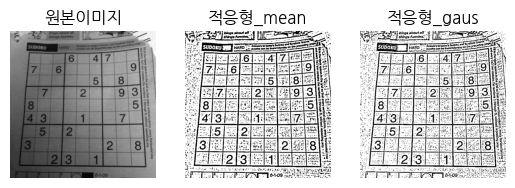

In [37]:
# 이진화 - opencv 방식 : 적응형 방식
th_mean = cv2.adaptiveThreshold(img, MAX_VALUE, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)
th_gaus = cv2.adaptiveThreshold(img, MAX_VALUE, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

printPolts(1, 3, ['원본이미지', '적응형_mean', '적응형_gaus'], [img, th_mean, th_gaus], ['gray'])

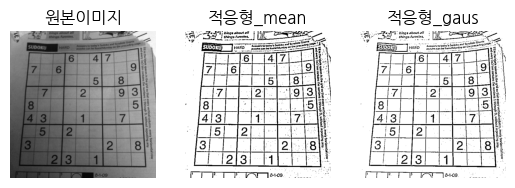

In [ ]:
img = cv2.imread('../Data/images/sudoku.png', cv2.IMREAD_GRAYSCALE)
th_mean = cv2.adaptiveThreshold(img, MAX_VALUE, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 9, 5)
th_gaus = cv2.adaptiveThreshold(img, MAX_VALUE, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 9, 5)

printPolts(1, 3, ['원본이미지', '적응형_mean', '적응형_gaus'], [img, th_mean, th_gaus], ['gray'])